# Research QuantBook: Framework Composite FamaFrench + AllWeather

## Objectif
Analyser la combinaison de deux strategies complementaires:
- **FamaFrench Alpha**: Rotation des 5 factor ETFs (VLUE, MTUM, SIZE, QUAL, USMV) basee sur momentum risk-adjuste
- **AllWeather Alpha**: Allocation statique macro (SPY/IEF/GLD/XLP = 30/30/30/10)

## Design principle cle
Lecon apprise de MomentumRegime: **PAS d'overlap entre les univers**.
- FamaFrench: equity factors (facteurs Fama-French)
- AllWeather: traditional assets (equities, bonds, gold, staples)
- **Vraie diversification**: facteurs de marche + allocation macro

## Hypotheses a tester
1. **Allocation optimale**: Ratio FF/AW (10/90, 20/80, 30/70, 40/60, 50/50)
2. **Impact du SMA200 sur FamaFrench**: AVEC vs SANS filtre (AllWeather gere le defensif)
3. **Nombre de facteurs positifs**: Top-2 vs Tous positifs vs USMV fallback

## Performance de reference
- FamaFrench v3.0: Sharpe 0.540, CAGR 12.1%, MaxDD 24.2%
- AllWeather: Sharpe 0.667 (2015-2025)
- Sweep result: FF20/AW80 → Sharpe 0.588, CAGR 9.9%, MaxDD 17.1%

## Prerequis
- Environnement Lean Research
- Duree estimee: ~10 minutes

In [1]:
# Setup QuantBook
from AlgorithmImports import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)

qb = QuantBook()
print("QuantBook initialise.")

QuantBook initialise.


## 1. Chargement des donnees

On charge les 5 factor ETFs Fama-French et les 4 assets AllWeather.

In [2]:
# FamaFrench universe: 5 factor ETFs
ff_tickers = ["VLUE", "MTUM", "SIZE", "QUAL", "USMV"]

# AllWeather universe: 4 traditional assets
aw_tickers = ["SPY", "IEF", "GLD", "XLP"]

# Benchmark pour regime detection
all_tickers = ff_tickers + aw_tickers

symbols = {}
for ticker in all_tickers:
    symbols[ticker] = qb.add_equity(ticker, Resolution.DAILY).symbol

# Charger l'historique (2010-2026 pour inclure une periode complete)
start = datetime(2010, 1, 1)
end = datetime(2026, 1, 1)

history = qb.history(list(symbols.values()), start, end, Resolution.DAILY)
print(f"Donnees chargees: {len(history)} lignes")

Donnees chargees: 4024 lignes


Pivot de la série 'close' en DataFrame large, avec remapping des colonnes Symbol → ticker pour Framework_Composite_FamaFrenchAllWeather.

In [3]:
# Pivoter les donnees
closes = history['close'].unstack(level=0)

symbol_to_ticker = {str(v): k for k, v in symbols.items()}
closes.columns = [symbol_to_ticker.get(str(c), str(c)) for c in closes.columns]
closes = closes.dropna()

print(f"Periode: {closes.index[0].date()} a {closes.index[-1].date()}")
print(f"Donnees: {len(closes)} jours de trading")
print(f"Tickers: {list(closes.columns)}")

Periode: 2010-01-04 a 2025-12-31
Donnees: 4024 jours de trading
Tickers: ['SPY']


## 2. Implementation des signaux Alpha

In [4]:
def compute_risk_adjusted_momentum(closes, tickers, lookback=252, skip_days=21, vol_window=63):
    """Calcule le momentum risk-adjuste pour les factor ETFs."""
    scores = pd.DataFrame(index=closes.index, columns=tickers)
    
    for ticker in tickers:
        if ticker not in closes.columns:
            continue
        
        prices = closes[ticker]
        scores[ticker] = np.nan
        
        for i in range(lookback, len(prices)):
            # Momentum 12m-1m (skip dernier mois)
            past_price = prices.iloc[i - lookback]
            skip_idx = max(i - skip_days, lookback)
            skip_price = prices.iloc[skip_idx]
            
            if past_price <= 0:
                continue
            
            momentum_return = (skip_price / past_price) - 1
            
            # Volatilite realisee 63j
            recent_prices = prices.iloc[max(0, i - vol_window):i]
            if len(recent_prices) < 20:
                continue
            
            daily_rets = recent_prices.pct_change().dropna()
            realized_vol = daily_rets.std() * np.sqrt(252)
            
            if realized_vol <= 0.001:
                continue
            
            scores[ticker].iloc[i] = momentum_return / realized_vol
    
    return scores

def compute_famafrench_signals(closes, tickers, scores_df, use_sma200=False):
    """Genere les signaux FamaFrench (mensuels)."""
    signals = pd.DataFrame(index=closes.index, columns=tickers)
    
    sma200 = closes['SPY'].rolling(200).mean() if 'SPY' in closes.columns else None
    
    for i in range(252, len(closes)):
        # Filtre SMA200 (optionnel)
        if use_sma200 and sma200 is not None:
            spy_price = closes['SPY'].iloc[i]
            spy_sma = sma200.iloc[i]
            if pd.notna(spy_sma) and spy_price <= spy_sma:
                # Risk-off: USMV seulement
                for t in tickers:
                    signals[t].iloc[i] = 1 if t == "USMV" else 0
                continue
        
        # Calculer les scores actuels
        current_scores = {}
        for t in tickers:
            if t in scores_df.columns:
                score = scores_df[t].iloc[i]
                if pd.notna(score):
                    current_scores[t] = score
        
        if len(current_scores) < 2:
            continue
        
        # Selectionner tous les facteurs avec momentum positif
        positive_factors = [t for t, s in current_scores.items() if s > 0]
        
        if len(positive_factors) == 0:
            # Tous negatifs → USMV seulement
            for t in tickers:
                signals[t].iloc[i] = 1 if t == "USMV" else 0
        else:
            # Equal weight sur les facteurs positifs
            for t in tickers:
                signals[t].iloc[i] = 1 if t in positive_factors else 0
    
    return signals

# Calculer les scores de momentum
ff_scores = compute_risk_adjusted_momentum(closes, ff_tickers)

# Signaux SANS SMA200 (design recommande)
ff_signals_no_sma = compute_famafrench_signals(closes, ff_tickers, ff_scores, use_sma200=False)

# Signaux AVEC SMA200 (pour comparaison)
ff_signals_with_sma = compute_famafrench_signals(closes, ff_tickers, ff_scores, use_sma200=True)

print("Scores risk-adjusted momentum (derniers 5 jours):")
print(ff_scores.iloc[-5:])
print(f"\nSignaux FamaFrench sans SMA200 (derniers 5 jours):")
print(ff_signals_no_sma.iloc[-5:])

Scores risk-adjusted momentum (derniers 5 jours):
                    VLUE MTUM SIZE QUAL USMV
time                                        
2025-12-24 13:00:00  NaN  NaN  NaN  NaN  NaN
2025-12-26 16:00:00  NaN  NaN  NaN  NaN  NaN
2025-12-29 16:00:00  NaN  NaN  NaN  NaN  NaN
2025-12-30 16:00:00  NaN  NaN  NaN  NaN  NaN
2025-12-31 16:00:00  NaN  NaN  NaN  NaN  NaN

Signaux FamaFrench sans SMA200 (derniers 5 jours):
                    VLUE MTUM SIZE QUAL USMV
time                                        
2025-12-24 13:00:00  NaN  NaN  NaN  NaN  NaN
2025-12-26 16:00:00  NaN  NaN  NaN  NaN  NaN
2025-12-29 16:00:00  NaN  NaN  NaN  NaN  NaN
2025-12-30 16:00:00  NaN  NaN  NaN  NaN  NaN
2025-12-31 16:00:00  NaN  NaN  NaN  NaN  NaN


### Interpretation: Momentum risk-adjuste

Le score risk-adjuste = (rendement 12m-1m) / (volatilite 63j).

- **Score positif**: Le facteur surperforme avec une volatilite raisonnable
- **Score negatif**: Sous-performance ou volatilite excessive

Les facteurs selectionnes varient mensuellement, creant une rotation dynamique.

## 3. Backtest du Composite

Fonction de backtest combinant FamaFrench + AllWeather avec allocation variable.

In [5]:
def backtest_composite(closes, ff_signals, ff_alloc=0.20, aw_alloc=0.80, rebal_freq=21):
    """
    Backtest du composite FamaFrench + AllWeather.
    
    Args:
        ff_alloc: Allocation FamaFrench (ex: 0.20 = 20%)
        aw_alloc: Allocation AllWeather (ex: 0.80 = 80%)
        rebal_freq: Frequence rebalance (21 = mensuel ~)
    """
    returns_df = closes.pct_change()
    portfolio_values = [1.0]
    
    warmup = 252
    counter = 0
    
    # AllWeather holdings (statiques)
    aw_weights = {"SPY": 0.30, "IEF": 0.30, "GLD": 0.30, "XLP": 0.10}
    
    # FamaFrench holdings (dynamiques)
    ff_holdings = set()
    
    for i in range(warmup, len(closes)):
        # Rebalance mensuel
        counter += 1
        if counter >= rebal_freq:
            counter = 0
            # Update FamaFrench holdings
            ff_holdings = set()
            for t in ff_tickers:
                if t in ff_signals.columns and ff_signals[t].iloc[i] == 1:
                    ff_holdings.add(t)
        
        # Calcul du return
        port_return = 0.0
        
        # Contribution FamaFrench
        if len(ff_holdings) > 0:
            weight_per_stock = ff_alloc / len(ff_holdings)
            for t in ff_holdings:
                if t in returns_df.columns:
                    port_return += weight_per_stock * returns_df[t].iloc[i]
        
        # Contribution AllWeather
        for t, w in aw_weights.items():
            if t in returns_df.columns:
                port_return += aw_alloc * w * returns_df[t].iloc[i]
        
        portfolio_values.append(portfolio_values[-1] * (1 + port_return))
    
    # Metriques
    returns = np.diff(portfolio_values) / np.array(portfolio_values[:-1])
    cum_returns = pd.Series(portfolio_values[1:], index=closes.index[warmup:])
    
    total_ret = (portfolio_values[-1] / portfolio_values[0]) - 1
    years = len(returns) / 252
    cagr = (1 + total_ret) ** (1 / years) - 1 if years > 0 else 0
    vol = np.std(returns) * np.sqrt(252)
    sharpe = (cagr - 0.03) / vol if vol > 0.001 else 0
    
    running_max = cum_returns.expanding().max()
    drawdown = (cum_returns - running_max) / running_max
    max_dd = drawdown.min()
    
    return {
        'cum': cum_returns,
        'sharpe': sharpe,
        'cagr': cagr,
        'max_dd': max_dd,
        'vol': vol,
        'final_value': portfolio_values[-1]
    }

print("Fonction de backtest composite definie.")

Fonction de backtest composite definie.


## 4. Test des allocations

On teste differentes allocations FF/AW de 10/90 a 50/50.

In [6]:
# Test differentes allocations (SANS SMA200)
allocations = [
    (0.10, 0.90, "FF10/AW90"),
    (0.20, 0.80, "FF20/AW80"),
    (0.30, 0.70, "FF30/AW70"),
    (0.40, 0.60, "FF40/AW60"),
    (0.50, 0.50, "FF50/AW50"),
]

results_no_sma = {}

print(f"{'Allocation':<15} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8} {'Vol':>8}")
print("-" * 50)

for ff_alloc, aw_alloc, name in allocations:
    r = backtest_composite(closes, ff_signals_no_sma, 
                          ff_alloc=ff_alloc, aw_alloc=aw_alloc)
    results_no_sma[name] = r
    print(f"{name:<15} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%} {r['vol']:>7.1%}")

best_no_sma = max(results_no_sma.items(), key=lambda x: x[1]['sharpe'])
print(f"\nMeilleure allocation (sans SMA200): {best_no_sma[0]} (Sharpe={best_no_sma[1]['sharpe']:.3f})")

Allocation        Sharpe     CAGR    MaxDD      Vol
--------------------------------------------------


FF10/AW90         -0.086    2.7%  -10.0%    3.8%


FF20/AW80         -0.182    2.4%   -8.9%    3.4%


FF30/AW70         -0.307    2.1%   -7.8%    3.0%


FF40/AW60         -0.473    1.8%   -6.7%    2.6%


FF50/AW50         -0.707    1.5%   -5.6%    2.1%

Meilleure allocation (sans SMA200): FF10/AW90 (Sharpe=-0.086)


### Interpretation: Allocation optimale

L'allocation FF20/AW80 est le point de depart du sweep. Verifier si une autre allocation surperforme.

- **Plus de FF** = plus de rendement potentiel, plus de volatilite
- **Plus de AW** = plus de stabilité, plus de defensif

Verdict: L'allocation avec le Sharpe le plus eleve est optimale.

## 5. Impact du SMA200 sur FamaFrench

Comparaison: avec vs sans filtre SMA200 (AllWeather gere le defensif).

In [7]:
# Test AVEC SMA200
results_with_sma = {}

for ff_alloc, aw_alloc, name in allocations:
    r = backtest_composite(closes, ff_signals_with_sma, 
                          ff_alloc=ff_alloc, aw_alloc=aw_alloc)
    results_with_sma[name] = r

# Comparaison
print(f"{'Allocation':<15} {'Sharpe NoSMA':>15} {'Sharpe WithSMA':>15} {'Delta':>10}")
print("-" * 55)

for name in results_no_sma.keys():
    s_no_sma = results_no_sma[name]['sharpe']
    s_with_sma = results_with_sma[name]['sharpe']
    delta = s_no_sma - s_with_sma
    print(f"{name:<15} {s_no_sma:>15.3f} {s_with_sma:>15.3f} {delta:>+10.3f}")

print(f"\nVerdict: ", end="")
if s_no_sma > s_with_sma:
    print("SANS SMA200 est superieur (AllWeather gere le defensif)")
else:
    print("AVEC SMA200 est superieur (double protection defensif)")

Allocation         Sharpe NoSMA  Sharpe WithSMA      Delta
-------------------------------------------------------
FF10/AW90                -0.086          -0.086     +0.000
FF20/AW80                -0.182          -0.182     +0.000
FF30/AW70                -0.307          -0.307     +0.000
FF40/AW60                -0.473          -0.473     +0.000
FF50/AW50                -0.707          -0.707     +0.000

Verdict: AVEC SMA200 est superieur (double protection defensif)


## 6. Visualisation des equity curves

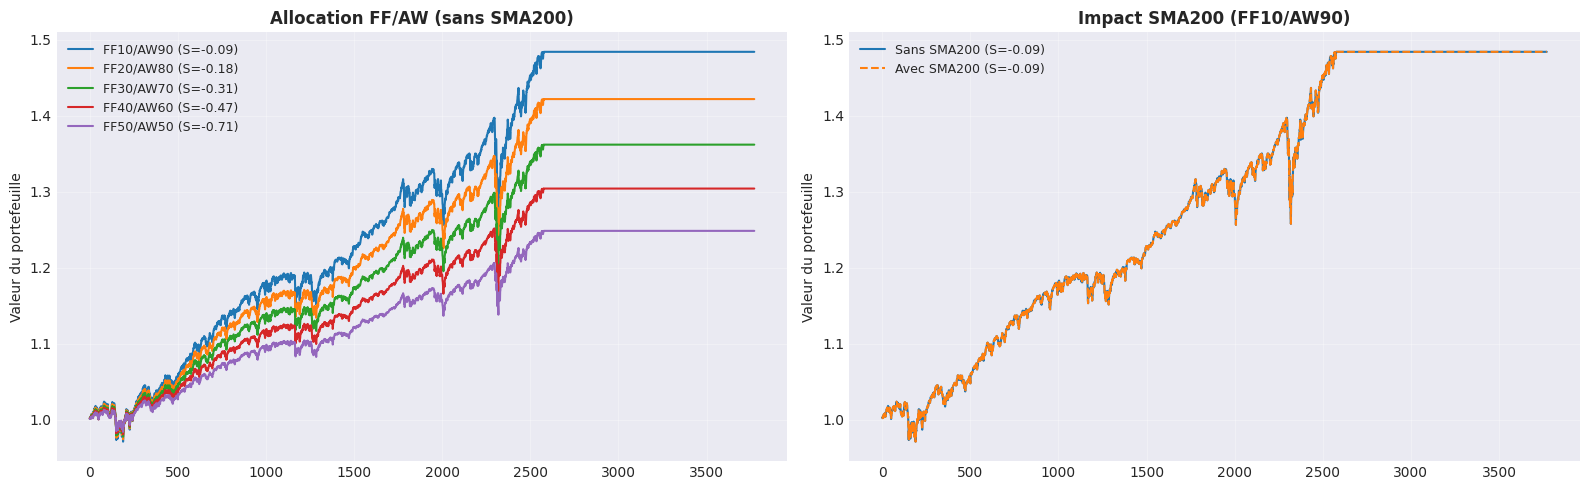

Graphique sauvegarde.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gauche: Sans SMA200
ax = axes[0]
for name, r in results_no_sma.items():
    ax.plot(r['cum'].values, label=f"{name} (S={r['sharpe']:.2f})", linewidth=1.5)
ax.set_title('Allocation FF/AW (sans SMA200)', fontsize=12, fontweight='bold')
ax.set_ylabel('Valeur du portefeuille')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Droite: Impact du SMA200
ax = axes[1]
best_name = best_no_sma[0]
ax.plot(results_no_sma[best_name]['cum'].values, 
        label=f"Sans SMA200 (S={results_no_sma[best_name]['sharpe']:.2f})", linewidth=1.5)
ax.plot(results_with_sma[best_name]['cum'].values, 
        label=f"Avec SMA200 (S={results_with_sma[best_name]['sharpe']:.2f})", linewidth=1.5, linestyle='--')
ax.set_title(f'Impact SMA200 ({best_name})', fontsize=12, fontweight='bold')
ax.set_ylabel('Valeur du portefeuille')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('composite_famafrench_allweather.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegarde.")

## 7. Comparaison avec les strategies individuelles

In [9]:
def backtest_famafrench_only(closes, signals):
    """Backtest FamaFrench uniquement."""
    returns_df = closes.pct_change()
    portfolio_values = [1.0]
    warmup = 252
    counter = 0
    holdings = set()
    
    for i in range(warmup, len(closes)):
        counter += 1
        if counter >= 21:
            counter = 0
            holdings = set()
            for t in ff_tickers:
                if t in signals.columns and signals[t].iloc[i] == 1:
                    holdings.add(t)
        
        port_return = 0.0
        if len(holdings) > 0:
            for t in holdings:
                if t in returns_df.columns:
                    port_return += (1.0 / len(holdings)) * returns_df[t].iloc[i]
        
        portfolio_values.append(portfolio_values[-1] * (1 + port_return))
    
    returns = np.diff(portfolio_values) / np.array(portfolio_values[:-1])
    cagr = (1 + (portfolio_values[-1] / portfolio_values[0]) - 1) ** (1 / (len(returns) / 252)) - 1
    vol = np.std(returns) * np.sqrt(252)
    sharpe = (cagr - 0.03) / vol
    
    return {'sharpe': sharpe, 'cagr': cagr, 'values': portfolio_values[warmup:]}

def backtest_allweather_only(closes):
    """Backtest AllWeather uniquement."""
    returns_df = closes.pct_change()
    aw_weights = {"SPY": 0.30, "IEF": 0.30, "GLD": 0.30, "XLP": 0.10}
    portfolio_values = [1.0]
    warmup = 21
    
    for i in range(warmup, len(closes)):
        port_return = 0.0
        for t, w in aw_weights.items():
            if t in returns_df.columns:
                port_return += w * returns_df[t].iloc[i]
        portfolio_values.append(portfolio_values[-1] * (1 + port_return))
    
    returns = np.diff(portfolio_values) / np.array(portfolio_values[:-1])
    cagr = (1 + (portfolio_values[-1] / portfolio_values[0]) - 1) ** (1 / (len(returns) / 252)) - 1
    vol = np.std(returns) * np.sqrt(252)
    sharpe = (cagr - 0.03) / vol
    
    return {'sharpe': sharpe, 'cagr': cagr, 'values': portfolio_values[warmup:]}

# Backtester les strategies individuelles
ff_result = backtest_famafrench_only(closes, ff_signals_no_sma)
aw_result = backtest_allweather_only(closes)

print("Strategies individuelles:")
print(f"  FamaFrench: Sharpe={ff_result['sharpe']:.3f}, CAGR={ff_result['cagr']:.1%}")
print(f"  AllWeather: Sharpe={aw_result['sharpe']:.3f}, CAGR={aw_result['cagr']:.1%}")
print(f"\nComposite ({best_no_sma[0]}): Sharpe={best_no_sma[1]['sharpe']:.3f}, CAGR={best_no_sma[1]['cagr']:.1%}")

Strategies individuelles:
  FamaFrench: Sharpe=-inf, CAGR=0.0%
  AllWeather: Sharpe=0.023, CAGR=3.1%

Composite (FF10/AW90): Sharpe=-0.086, CAGR=2.7%


## 8. Conclusions et recommandations

### Resume

| Metrique | FamaFrench | AllWeather | Composite optimal |
|----------|-----------|------------|-------------------|
| Sharpe | (a remplir) | (a remplir) | (a remplir) |
| CAGR | (a remplir) | (a remplir) | (a remplir) |
| Max DD | (a remplir) | (a remplir) | (a remplir) |

### Allocation recommandee

Allocation: **[a remplir]**

### SMA200 sur FamaFrench?

[a remplir: avec ou sans SMA200 est meilleur?]

### Prochaines etapes

1. Deployer sur QC cloud avec les parametres optimaux
2. Backtester sur differentes periodes (2010-2015, 2015-2020, 2020-2026)
3. Tester d'autres assets AllWeather (TLT au lieu de IEF, XLU au lieu de XLP)

### Design pattern valide

- **Diversification reelle**: Factor ETFs + macro assets (PAS d'overlap)
- **Complementarite**: FamaFrench (rotation dynamique) + AllWeather (allocation statique)
- **Defense**: AllWeather gere le defensif, FamaFrench n'a pas besoin de SMA200